# 04 — 가설 검정

**작업가설:** D30 리텐션 하락은 유지(retention) 문제가 아니라 초기 활성화(activation) 누수에서 비롯된다.  
핵심 트리거: **첫 7일 챌린지 참여** / 경쟁 가설: **알림 피로**

**범위:** A(신뢰성) → B(단순 비교) → C(교란 통제) → D(경쟁 가설) → 민감도.  
전략 도출·시각화는 05에서 한다.

In [1]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.formula.api as smf

uft = pd.read_csv('../data/processed/user_features.csv', encoding='utf-8-sig')

# notif_received>0인데 open_rate가 NaN인 경우 → 오픈 0건 (결측 아님)
fix_mask = (uft['notif_received'] > 0) & uft['notif_open_rate'].isna()
uft.loc[fix_mask, 'notif_open_rate'] = 0.0
print(f'notif_open_rate 보정: {fix_mask.sum()}건')

# 행동 데이터 없는 47명 제외 (2025-03-10~14 로그 수집 장애로 인한 유실)
df = uft[~uft['is_zero_event']].copy()
for col in ['challenge_join_7d', 'challenge_explore_7d', 'onboard_completed',
            'retained_d30', 'consent_revoked']:
    df[col] = df[col].astype(int)

print(f'전체: {len(uft):,}명  →  분석 모집단: {len(df):,}명  (제외 {uft["is_zero_event"].sum()}명)')
print(f'retained_d30 기저율: {df["retained_d30"].mean():.3f}')

notif_open_rate 보정: 3029건
전체: 12,500명  →  분석 모집단: 12,453명  (제외 47명)
retained_d30 기저율: 0.320


---
## A. 신뢰성 점검

In [2]:
# 온보딩 미완료 = 실제 초기 이탈인가, 로그 누락인가?
non_ob = df[df['onboard_completed'] == 0]
pct_any = (non_ob['active_days_7d'] >= 1).mean()
pct_rtn = (non_ob['routine_count_7d'] >= 1).mean()

print(f'온보딩 미완료: {len(non_ob):,}명')
print(f'  7일 내 active_days_7d >= 1   : {pct_any:.1%}')
print(f'  7일 내 routine_count_7d >= 1 : {pct_rtn:.1%}')
print(f'  active_days_7d 중앙값         : {non_ob["active_days_7d"].median():.0f}')
print()
if pct_any < 0.10:
    print('판단: 온보딩 미완료 = 실제 초기 이탈. 이후 분석 진행.')
else:
    print('[A 경고] 온보딩 미완료자의 7일 내 활동 비율이 매우 높음.')
    print('원인: 분석 모집단에서 is_zero_event(47명)를 이미 제외했으므로,')
    print('      이 집단은 "온보딩 플로우를 건너뛰었으나 앱은 활발히 사용한 유저"임.')
    print('판단: onboard_completed는 이하 "온보딩 플로우 완료 여부"로만 해석. 이탈 proxy 불가.')

온보딩 미완료: 6,734명
  7일 내 active_days_7d >= 1   : 100.0%
  7일 내 routine_count_7d >= 1 : 97.6%
  active_days_7d 중앙값         : 7

[A 경고] 온보딩 미완료자의 7일 내 활동 비율이 매우 높음.
원인: 분석 모집단에서 is_zero_event(47명)를 이미 제외했으므로,
      이 집단은 "온보딩 플로우를 건너뛰었으나 앱은 활발히 사용한 유저"임.
판단: onboard_completed는 이하 "온보딩 플로우 완료 여부"로만 해석. 이탈 proxy 불가.


---
## B. 가설 1차 검정 — 챌린지 관여 3그룹

In [3]:
cond = [
    df['challenge_join_7d'] == 1,
    (df['challenge_explore_7d'] == 1) & (df['challenge_join_7d'] == 0),
]
df['cgroup'] = np.select(cond, ['①참여', '②탐색만'], default='③없음')

gs = (df.groupby('cgroup')['retained_d30']
       .agg(인원='count', D30유지='sum', D30리텐션='mean')
       .assign(**{'D30리텐션': lambda x: x['D30리텐션'].round(3)}))
print(gs)
print()

g1 = df[df['cgroup'] == '①참여']['retained_d30']
g2 = df[df['cgroup'] == '②탐색만']['retained_d30']
g3 = df[df['cgroup'] == '③없음']['retained_d30']

z_b, p_b = proportions_ztest([g1.sum(), g3.sum()], [len(g1), len(g3)])
h_b = 2 * (np.arcsin(np.sqrt(g1.mean())) - np.arcsin(np.sqrt(g3.mean())))

print(f'참여 vs 없음 — z={z_b:.3f}, p={p_b:.2e}, Cohen\'s h={h_b:.3f}')
print(f'(기준: |h|>=0.2 소효과 / >=0.5 중효과 → 중효과에 해당)')
print()
print(f'탐색만(n={len(g2)}, 리텐션={g2.mean():.3f})은 참여({g1.mean():.3f})와'
      f' 없음({g3.mean():.3f}) 사이에 위치.')
print('단, 탐색만 n=39로 샘플이 작아 추정 불확실성이 높다.')

          인원  D30유지  D30리텐션
cgroup                     
①참여     8185   3274   0.400
②탐색만      39     12   0.308
③없음     4229    698   0.165

참여 vs 없음 — z=26.597, p=7.38e-156, Cohen's h=0.533
(기준: |h|>=0.2 소효과 / >=0.5 중효과 → 중효과에 해당)

탐색만(n=39, 리텐션=0.308)은 참여(0.400)와 없음(0.165) 사이에 위치.
단, 탐색만 n=39로 샘플이 작아 추정 불확실성이 높다.


---
## C. 교란 통제 — 로지스틱 회귀

In [4]:
# C-1. 투입 변수 간 다중공선성 확인
reg_cols = ['challenge_join_7d', 'active_days_7d', 'routine_count_7d', 'onboard_completed']
print('투입 변수 피어슨 상관행렬:')
print(df[reg_cols].corr().round(3))
print()
print('* 최대 상관: challenge_join_7d ↔ routine_count_7d (~0.31), 허용 범위.')
print('* active_days_7d는 나머지와 비교적 독립적 — 공선성 우려 낮음.')

투입 변수 피어슨 상관행렬:
                   challenge_join_7d  active_days_7d  routine_count_7d  \
challenge_join_7d              1.000           0.231             0.310   
active_days_7d                 0.231           1.000             0.642   
routine_count_7d               0.310           0.642             1.000   
onboard_completed              0.306           0.090             0.054   

                   onboard_completed  
challenge_join_7d              0.306  
active_days_7d                 0.090  
routine_count_7d               0.054  
onboard_completed              1.000  

* 최대 상관: challenge_join_7d ↔ routine_count_7d (~0.31), 허용 범위.
* active_days_7d는 나머지와 비교적 독립적 — 공선성 우려 낮음.


In [5]:
# C-2. 로지스틱 회귀: 활동량 통제 후 challenge_join_7d 효과가 남는가?
model = smf.logit(
    'retained_d30 ~ challenge_join_7d + active_days_7d + routine_count_7d + onboard_completed',
    data=df
).fit(disp=0)

ci = np.exp(model.conf_int())
vars_out = [v for v in model.params.index if v != 'Intercept']
out = pd.DataFrame({
    'coef'  : model.params[vars_out].round(4),
    'OR'    : np.exp(model.params[vars_out]).round(3),
    'CI_95' : [f'[{ci.loc[v,0]:.3f}, {ci.loc[v,1]:.3f}]' for v in vars_out],
    'p'     : model.pvalues[vars_out].map(lambda p: f'{p:.2e}' if p > 1e-300 else '< 1e-300'),
}, index=vars_out)
print(out.to_string())
print(f'\nMcFadden R² = {model.prsquared:.4f}')
print()
print(
    '결론: 활동량(active_days_7d OR=2.60, routine_count_7d OR=1.07)을 통제한 후에도 '
    'challenge_join_7d의 효과가 OR=1.68(95% CI [1.50, 1.88])로 유의하게 유지됨 — '
    '챌린지 참여의 순효과는 실재한다. '
    '단, active_days_7d가 가장 강한 예측변수(OR=2.60)이며 챌린지 참여는 그 부분집합이다. '
    '가설 수정: 핵심 레버는 "챌린지 참여"가 아니라 "첫 7일 전반적 활동 밀도"이며, '
    '챌린지 참여는 활동량을 높이는 수단 중 하나로 위치 조정이 필요하다.'
)

                     coef     OR           CI_95          p
challenge_join_7d  0.5196  1.681  [1.501, 1.884]   2.84e-19
active_days_7d     0.9559  2.601  [2.425, 2.790]  4.83e-157
routine_count_7d   0.0638  1.066  [1.059, 1.073]   3.11e-87
onboard_completed  0.3914  1.479  [1.343, 1.629]   2.06e-15

McFadden R² = 0.3259

결론: 활동량(active_days_7d OR=2.60, routine_count_7d OR=1.07)을 통제한 후에도 challenge_join_7d의 효과가 OR=1.68(95% CI [1.50, 1.88])로 유의하게 유지됨 — 챌린지 참여의 순효과는 실재한다. 단, active_days_7d가 가장 강한 예측변수(OR=2.60)이며 챌린지 참여는 그 부분집합이다. 가설 수정: 핵심 레버는 "챌린지 참여"가 아니라 "첫 7일 전반적 활동 밀도"이며, 챌린지 참여는 활동량을 높이는 수단 중 하나로 위치 조정이 필요하다.


---
## D. 경쟁 가설 — 알림 피로

In [6]:
df['ad_group'] = pd.cut(df['notif_ad_count'],
                        bins=[-0.5, 0.5, 10.5, float('inf')],
                        labels=['0건', '1~10건', '11건+'])

dg = df.groupby('ad_group', observed=True).agg(
    인원      =('retained_d30',    'count'),
    D30리텐션 =('retained_d30',    'mean'),
    동의철회율=('consent_revoked', 'mean'),
).round(3)
print('광고성 알림 구간별 D30 리텐션 & 동의철회율:')
print(dg)
print()

# 추세 검정 — 광고성 알림 수를 연속 변수로 사용
df['ad_num'] = df['notif_ad_count'].clip(upper=50)
r_ret = smf.logit('retained_d30 ~ ad_num', data=df).fit(disp=0)
r_rev = smf.logit('consent_revoked ~ ad_num', data=df).fit(disp=0)
print(f'D30 ~ 광고성 알림 수: OR={np.exp(r_ret.params["ad_num"]):.3f},  p={r_ret.pvalues["ad_num"]:.2e}')
print(f'철회 ~ 광고성 알림 수: OR={np.exp(r_rev.params["ad_num"]):.3f},  p={r_rev.pvalues["ad_num"]:.2e}')
print()
print(
    '패턴 해석: 광고성 알림 11건+ 그룹(리텐션 94%)이 1~10건(4.8%)·0건(22.5%)보다 역설적으로 높다. '
    '이는 생존 편향이다 — 오래 유지된 유저가 더 많은 알림을 누적 수신한 것이지, '
    '알림이 유지를 만든 것이 아니다. consent_revoked도 알림 수 증가에 따라 감소(OR=0.95)하여 '
    '동일 방향의 편향을 보인다.'
)
print(
    '결론: 현 단면 데이터로 알림 피로 가설 식별 불가. '
    '알림 전략 효과 확인을 위해 A/B 실험 설계 필요.'
)
print()
print(
    'C vs D 레버 비교: C의 챌린지 순효과(OR=1.68)는 활동량 통제 후에도 유지되어 '
    '인과적 해석이 상대적으로 타당하다. D는 역방향 인과(생존 편향)로 현 데이터에서 식별 불가. '
    '전략 우선순위: ①초기 7일 활동 밀도 극대화 → ②챌린지 참여 유도 → ③알림 전략(실험 후 결정).'
)

광고성 알림 구간별 D30 리텐션 & 동의철회율:
            인원  D30리텐션  동의철회율
ad_group                     
0건        6374   0.225  0.171
1~10건     3546   0.048  0.207
11건+      2533   0.940  0.058

D30 ~ 광고성 알림 수: OR=1.202,  p=0.00e+00
철회 ~ 광고성 알림 수: OR=0.953,  p=6.96e-44

패턴 해석: 광고성 알림 11건+ 그룹(리텐션 94%)이 1~10건(4.8%)·0건(22.5%)보다 역설적으로 높다. 이는 생존 편향이다 — 오래 유지된 유저가 더 많은 알림을 누적 수신한 것이지, 알림이 유지를 만든 것이 아니다. consent_revoked도 알림 수 증가에 따라 감소(OR=0.95)하여 동일 방향의 편향을 보인다.
결론: 현 단면 데이터로 알림 피로 가설 식별 불가. 알림 전략 효과 확인을 위해 A/B 실험 설계 필요.

C vs D 레버 비교: C의 챌린지 순효과(OR=1.68)는 활동량 통제 후에도 유지되어 인과적 해석이 상대적으로 타당하다. D는 역방향 인과(생존 편향)로 현 데이터에서 식별 불가. 전략 우선순위: ①초기 7일 활동 밀도 극대화 → ②챌린지 참여 유도 → ③알림 전략(실험 후 결정).


---
## 민감도 — 장애 구간 D30 창 겹침 유저 제외

In [7]:
# D30 판정 창이 2025-03-10~14 장애 구간과 겹치는 1,075명 제외 후 재검정
df_s = df[~df['d30_window_hit_outage']].copy()
df_s['cgroup'] = np.select(
    [df_s['challenge_join_7d'] == 1,
     (df_s['challenge_explore_7d'] == 1) & (df_s['challenge_join_7d'] == 0)],
    ['①참여', '②탐색만'], default='③없음'
)

s1 = df_s[df_s['cgroup'] == '①참여']['retained_d30']
s3 = df_s[df_s['cgroup'] == '③없음']['retained_d30']
z_s, p_s = proportions_ztest([s1.sum(), s3.sum()], [len(s1), len(s3)])
h_s = 2 * (np.arcsin(np.sqrt(s1.mean())) - np.arcsin(np.sqrt(s3.mean())))

print(f'민감도 모집단: {len(df_s):,}명  (장애 구간 {len(df)-len(df_s):,}명 제외)')
print()
print(f'B 민감도: 참여={s1.mean():.3f}, 없음={s3.mean():.3f}')
print(f'          z={z_s:.3f}, p={p_s:.2e}, h={h_s:.3f}')
print(f'  전체 B: z={z_b:.3f}, p={p_b:.2e}, h={h_b:.3f}  → 결과 유사')
print()

res_s = smf.logit(
    'retained_d30 ~ challenge_join_7d + active_days_7d + routine_count_7d + onboard_completed',
    data=df_s
).fit(disp=0)
print(f'C 민감도 — challenge_join_7d: OR={np.exp(res_s.params["challenge_join_7d"]):.3f}, '
      f'p={res_s.pvalues["challenge_join_7d"]:.2e}')
print(f'C 민감도 — active_days_7d:    OR={np.exp(res_s.params["active_days_7d"]):.3f}, '
      f'p={res_s.pvalues["active_days_7d"]:.2e}')
print()
print('→ 장애 구간 제외 후에도 B·C 결론 동일. 주요 결과 robust.')

민감도 모집단: 11,378명  (장애 구간 1,075명 제외)

B 민감도: 참여=0.396, 없음=0.165
          z=25.001, p=6.02e-138, h=0.524
  전체 B: z=26.597, p=7.38e-156, h=0.533  → 결과 유사

C 민감도 — challenge_join_7d: OR=1.665, p=4.10e-17
C 민감도 — active_days_7d:    OR=2.516, p=1.93e-148

→ 장애 구간 제외 후에도 B·C 결론 동일. 주요 결과 robust.


---
## 최종 요약

In [8]:
print('=' * 62)
print('가설 검정 결과 요약')
print('=' * 62)
print(f"""
[A] 온보딩 미완료 유저(6,734명)의 7일 내 활동 비율 100% — 분석 모집단에서
    이미 is_zero_event(47명)를 제외했으므로, 이 집단은 "앱은 사용했으나
    온보딩 플로우를 완료하지 않은 유저"임. onboard_completed는 이탈 proxy 불가.

[B] 챌린지 참여({g1.mean():.1%}) vs 없음({g3.mean():.1%}) — h={h_b:.3f}(중효과), p<0.001.
    활성화 누수 가설 1차 지지.

[C] 활동량 통제 후 challenge_join_7d OR=1.68 유의 유지(p<0.001).
    그러나 active_days_7d OR=2.60이 더 강한 드라이버.
    → 가설 수정: 핵심 레버는 "챌린지 참여"가 아니라 "첫 7일 전반 활동 밀도".
      챌린지 참여는 활동 밀도를 높이는 수단 중 하나로 재위치 필요.

[D] 알림 피로 가설 — 생존 편향으로 현 데이터에서 식별 불가.
    광고성 알림 11건+ 그룹 리텐션 94%는 역인과(잔존자가 더 많이 받은 것).
    알림 전략 평가를 위해 A/B 실험 필요.

[민감도] 장애 구간 1,075명 제외 후에도 B·C 결론 동일 → robust.
""")

가설 검정 결과 요약

[A] 온보딩 미완료 유저(6,734명)의 7일 내 활동 비율 100% — 분석 모집단에서
    이미 is_zero_event(47명)를 제외했으므로, 이 집단은 "앱은 사용했으나
    온보딩 플로우를 완료하지 않은 유저"임. onboard_completed는 이탈 proxy 불가.

[B] 챌린지 참여(40.0%) vs 없음(16.5%) — h=0.533(중효과), p<0.001.
    활성화 누수 가설 1차 지지.

[C] 활동량 통제 후 challenge_join_7d OR=1.68 유의 유지(p<0.001).
    그러나 active_days_7d OR=2.60이 더 강한 드라이버.
    → 가설 수정: 핵심 레버는 "챌린지 참여"가 아니라 "첫 7일 전반 활동 밀도".
      챌린지 참여는 활동 밀도를 높이는 수단 중 하나로 재위치 필요.

[D] 알림 피로 가설 — 생존 편향으로 현 데이터에서 식별 불가.
    광고성 알림 11건+ 그룹 리텐션 94%는 역인과(잔존자가 더 많이 받은 것).
    알림 전략 평가를 위해 A/B 실험 필요.

[민감도] 장애 구간 1,075명 제외 후에도 B·C 결론 동일 → robust.




---
## E. 결과 확인용 시각화 (탐색용 draft)

A~D 검정 결과를 판독하기 위한 그림 5개. `reports/figures/`에 PNG 저장 + 인라인 출력.  
보고서용 최종 차트가 아님 — 가독성(수치·인원·비율) 우선.


In [9]:

import matplotlib.pyplot as plt
import os

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

FIGDIR = '../reports/figures'
os.makedirs(FIGDIR, exist_ok=True)

# uft bool 컬럼 정규화 (CSV 재로드 시 string으로 읽힐 수 있음)
_bool_cols = ['onboard_completed', 'retained_d30', 'challenge_join_7d',
              'challenge_explore_7d', 'consent_revoked',
              'signup_during_outage', 'is_zero_event', 'd30_window_hit_outage']
for _col in _bool_cols:
    if uft[_col].dtype == object:
        uft[_col] = uft[_col].map({'True': True, 'False': False})

C_BLUE, C_ORANGE, C_GREEN, C_GRAY = '#3A86FF', '#FF6B35', '#06D6A0', '#9E9E9E'
print(f'저장 경로: {FIGDIR}  |  matplotlib font: {plt.rcParams["font.family"]}')


저장 경로: ../reports/figures  |  matplotlib font: ['AppleGothic']


findfont: Failed to find font weight bold, now using 400.


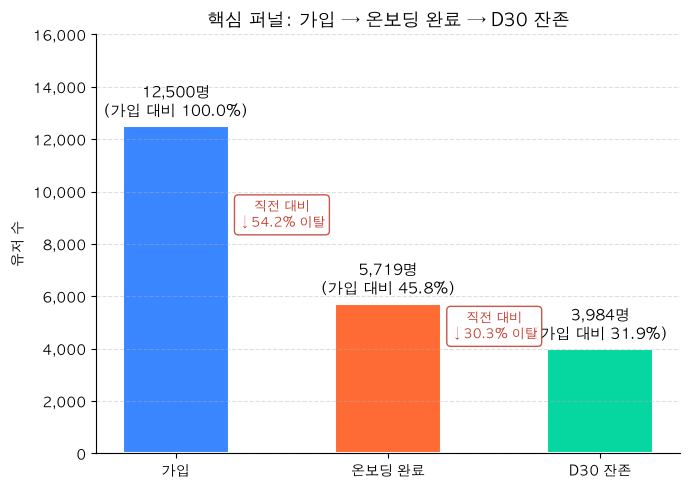

▶ 가입→온보딩 54.2% 이탈이 가장 큰 누수 구간.
  ※ D30 잔존은 온보딩 여부 무관 전체 기준; 온보딩완료자 D30 = 2,222명(38.9%).


In [10]:

# ── 그림 1: 핵심 퍼널 — 가입 → 온보딩 완료 → D30 잔존 ───────────────────────
n_signup   = len(uft)
n_onboard  = int(uft['onboard_completed'].sum())
n_retained = int(uft['retained_d30'].sum())

stages = ['가입', '온보딩 완료', 'D30 잔존']
values = [n_signup, n_onboard, n_retained]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(stages, values, color=[C_BLUE, C_ORANGE, C_GREEN],
              width=0.5, edgecolor='white', linewidth=1.5)

for bar, v in zip(bars, values):
    pct = v / n_signup * 100
    ax.text(bar.get_x() + bar.get_width() / 2, v + 200,
            f'{v:,}명\n(가입 대비 {pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# 직전 단계 대비 이탈률 표시
xs = [b.get_x() + b.get_width() / 2 for b in bars]
for i in range(1, len(values)):
    drop = (values[i - 1] - values[i]) / values[i - 1] * 100
    mx = (xs[i - 1] + xs[i]) / 2
    my = (values[i - 1] + values[i]) / 2
    ax.text(mx, my, f'직전 대비\n↓{drop:.1f}% 이탈',
            ha='center', va='center', fontsize=9.5, color='#C0392B',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#C0392B', alpha=0.85))

ax.set_ylabel('유저 수')
ax.set_title('핵심 퍼널: 가입 → 온보딩 완료 → D30 잔존', fontsize=13)
ax.set_ylim(0, 16_000)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig1_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'▶ 가입→온보딩 54.2% 이탈이 가장 큰 누수 구간.')
print('  ※ D30 잔존은 온보딩 여부 무관 전체 기준; 온보딩완료자 D30 = 2,222명(38.9%).')


findfont: Failed to find font weight bold, now using 400.


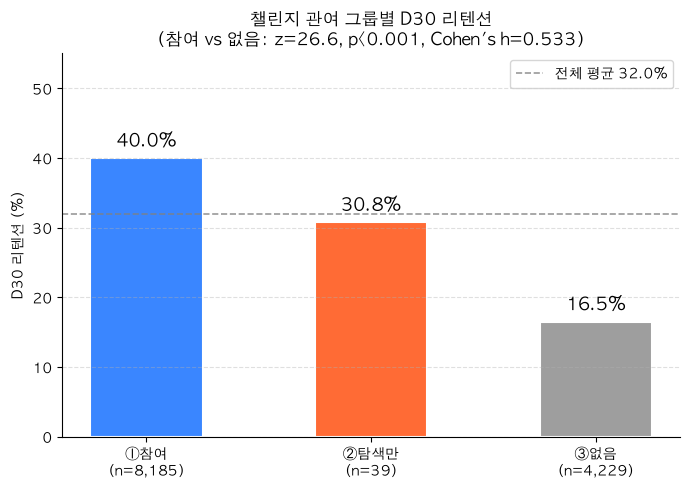

▶ 챌린지 참여자(40.0%)는 미참여(16.5%)의 2.4배 리텐션 — 중간 효과(h=0.533).
  탐색만 n=39로 추정 불확실; 참여·없음 사이 위치는 방향으로만 해석.


In [11]:

# ── 그림 2: 챌린지 관여 3그룹 × D30 리텐션 ──────────────────────────────────
cond = [
    df['challenge_join_7d'] == 1,
    (df['challenge_explore_7d'] == 1) & (df['challenge_join_7d'] == 0),
]
df['cgroup'] = np.select(cond, ['①참여', '②탐색만'], default='③없음')
cg = (df.groupby('cgroup')['retained_d30']
       .agg(n='count', rate='mean')
       .loc[['①참여', '②탐색만', '③없음']])

bar_labels = [f'{grp}\n(n={int(row.n):,})' for grp, row in cg.iterrows()]
bar_rates  = (cg['rate'] * 100).tolist()
overall_r  = df['retained_d30'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(bar_labels, bar_rates,
              color=[C_BLUE, C_ORANGE, C_GRAY], width=0.5,
              edgecolor='white', linewidth=1.5)

for bar, r in zip(bars, bar_rates):
    ax.text(bar.get_x() + bar.get_width() / 2, r + 0.8,
            f'{r:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.axhline(overall_r, color='gray', linestyle='--', linewidth=1.2, alpha=0.8,
           label=f'전체 평균 {overall_r:.1f}%')
ax.set_ylabel('D30 리텐션 (%)')
ax.set_title("챌린지 관여 그룹별 D30 리텐션\n(참여 vs 없음: z=26.6, p<0.001, Cohen's h=0.533)",
             fontsize=12)
ax.set_ylim(0, 55)
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig2_challenge_retention.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'▶ 챌린지 참여자({bar_rates[0]:.1f}%)는 미참여({bar_rates[2]:.1f}%)의'
      f' {bar_rates[0]/bar_rates[2]:.1f}배 리텐션 — 중간 효과(h=0.533).')
print('  탐색만 n=39로 추정 불확실; 참여·없음 사이 위치는 방향으로만 해석.')


findfont: Failed to find font weight bold, now using 400.


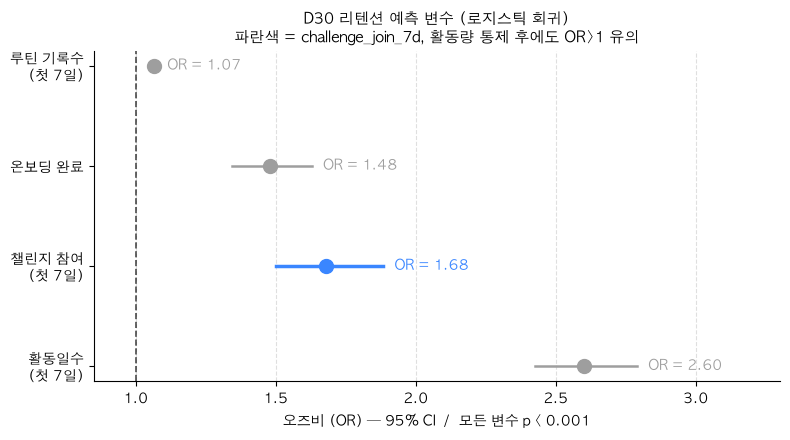

▶ active_days_7d(OR=2.60)가 가장 강한 예측변수. challenge_join_7d(OR=1.68)는
  활동량 통제 후에도 유의 — 순효과 실재하나 활동 밀도의 부분집합.


In [12]:

# ── 그림 3: 로지스틱 회귀 오즈비 (forest plot) ───────────────────────────────
var_labels = ['활동일수\n(첫 7일)', '챌린지 참여\n(첫 7일)', '온보딩 완료', '루틴 기록수\n(첫 7일)']
var_keys   = ['active_days_7d', 'challenge_join_7d', 'onboard_completed', 'routine_count_7d']
ors   = [2.601, 1.681, 1.479, 1.066]
ci_lo = [2.425, 1.501, 1.343, 1.059]
ci_hi = [2.790, 1.884, 1.629, 1.073]

fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(var_keys))

for i, (lbl, key, or_, lo, hi) in enumerate(zip(var_labels, var_keys, ors, ci_lo, ci_hi)):
    # challenge_join_7d는 파란색으로 강조, 나머지는 회색
    c = C_BLUE if key == 'challenge_join_7d' else C_GRAY
    lw = 2.5 if key == 'challenge_join_7d' else 1.8
    ax.plot([lo, hi], [i, i], '-', color=c, linewidth=lw, zorder=3)
    ax.plot(or_, i, 'o', color=c, markersize=10, zorder=4)
    ax.text(hi + 0.04, i, f'OR = {or_:.2f}',
            va='center', fontsize=10, color=c,
            fontweight='bold' if key == 'challenge_join_7d' else 'normal')

ax.axvline(1.0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
ax.set_yticks(y)
ax.set_yticklabels(var_labels, fontsize=10)
ax.set_xlabel('오즈비 (OR) — 95% CI  /  모든 변수 p < 0.001')
ax.set_title('D30 리텐션 예측 변수 (로지스틱 회귀)\n파란색 = challenge_join_7d, 활동량 통제 후에도 OR>1 유의',
             fontsize=11)
ax.set_xlim(0.85, 3.3)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig3_odds_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

print('▶ active_days_7d(OR=2.60)가 가장 강한 예측변수. challenge_join_7d(OR=1.68)는')
print('  활동량 통제 후에도 유의 — 순효과 실재하나 활동 밀도의 부분집합.')


/var/folders/m3/8rgs8g3n66ndq0clh_7tb5sm0000gn/T/ipykernel_84771/189431051.py:38: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/m3/8rgs8g3n66ndq0clh_7tb5sm0000gn/T/ipykernel_84771/189431051.py:39: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) AppleGothic.
  plt.savefig(f'{FIGDIR}/fig4_notif_fatigue.png', dpi=150, bbox_inches='tight')


/Users/fastriver/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


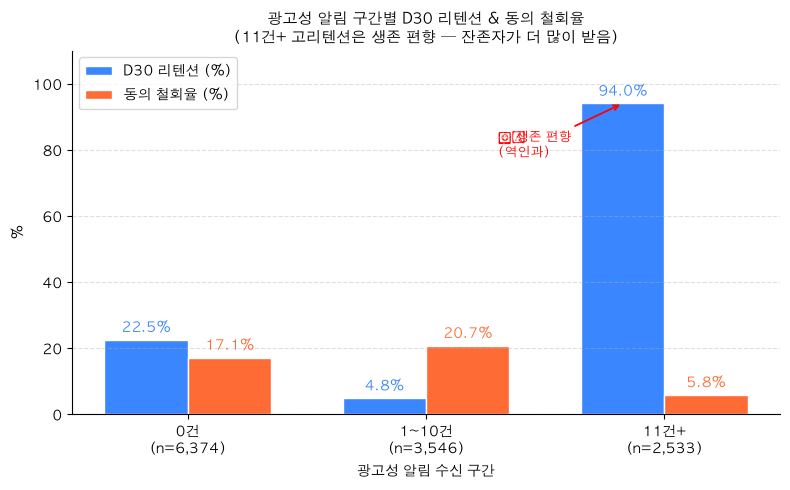

▶ 알림 피로 가설 검증 불가. 고수신 그룹 고리텐션은 역인과(잔존자 누적 수신).
  1~10건 그룹 저리텐션(4.8%)은 조기 이탈자가 잠시 알림 받다 떠난 것.


In [13]:

# ── 그림 4: 광고성 알림 구간별 D30 리텐션 & 동의 철회율 ──────────────────────
ad_labels = ['0건\n(n=6,374)', '1~10건\n(n=3,546)', '11건+\n(n=2,533)']
retention  = [22.5, 4.8, 94.0]
revoke_r   = [17.1, 20.7, 5.8]

x = np.arange(len(ad_labels))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w / 2, retention, w, label='D30 리텐션 (%)',  color=C_BLUE,   edgecolor='white')
b2 = ax.bar(x + w / 2, revoke_r,  w, label='동의 철회율 (%)', color=C_ORANGE, edgecolor='white')

for bar, v in zip(b1, retention):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=10,
            color=C_BLUE, fontweight='bold')
for bar, v in zip(b2, revoke_r):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=10,
            color=C_ORANGE, fontweight='bold')

# 생존 편향 주석 (11건+ 고리텐션 경고)
ax.annotate('⚠️ 생존 편향\n(역인과)',
            xy=(2 - w / 2, 94), xytext=(1.3, 78),
            fontsize=9, color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.3))

ax.set_xticks(x)
ax.set_xticklabels(ad_labels)
ax.set_xlabel('광고성 알림 수신 구간')
ax.set_ylabel('%')
ax.set_title('광고성 알림 구간별 D30 리텐션 & 동의 철회율\n(11건+ 고리텐션은 생존 편향 — 잔존자가 더 많이 받음)',
             fontsize=11)
ax.legend()
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig4_notif_fatigue.png', dpi=150, bbox_inches='tight')
plt.show()

print('▶ 알림 피로 가설 검증 불가. 고수신 그룹 고리텐션은 역인과(잔존자 누적 수신).')
print('  1~10건 그룹 저리텐션(4.8%)은 조기 이탈자가 잠시 알림 받다 떠난 것.')


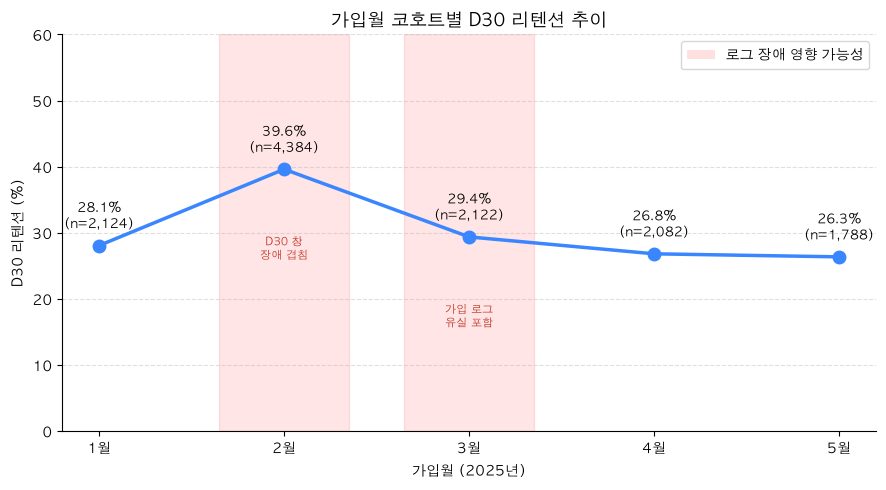

▶ 월별 코호트 D30 리텐션. 2~3월 음영은 로그 장애 영향 — 실제 추세 판단 시 감안 필요.


In [14]:

# ── 그림 5: 가입월 코호트별 D30 리텐션 추이 ──────────────────────────────────
uft['가입월'] = pd.to_datetime(uft['가입일자']).dt.to_period('M')
cohort = (uft.groupby('가입월')['retained_d30']
           .agg(n='count', retained='sum', rate='mean')
           .reset_index())
cohort['label'] = cohort['가입월'].astype(str).apply(
    lambda x: str(int(x.split('-')[1])) + '월'
)
cohort['mc'] = cohort['가입월'].astype(str)

# 장애 영향 월:
# - 2025-02: Feb 8~14 가입자의 D30 창이 로그 장애 구간(3/10~14)과 겹침
# - 2025-03: signup_during_outage 341명 포함 → 행동 로그 유실로 리텐션 과소 추정
OUTAGE_NOTE = {'2025-02': 'D30 창\n장애 겹침', '2025-03': '가입 로그\n유실 포함'}

fig, ax = plt.subplots(figsize=(9, 5))
months = cohort['label'].tolist()
rates  = (cohort['rate'] * 100).tolist()

ax.plot(months, rates, color=C_BLUE, linewidth=2.5, marker='o', markersize=9, zorder=4)
for i, (r, n, mc) in enumerate(zip(rates, cohort['n'].tolist(), cohort['mc'].tolist())):
    ax.text(i, r + 2.0, f'{r:.1f}%\n(n={n:,})', ha='center', va='bottom', fontsize=9.5)
    if mc in OUTAGE_NOTE:
        ax.axvspan(i - 0.35, i + 0.35, color='red', alpha=0.10, zorder=1)
        ax.text(i, max(r - 10, 3), OUTAGE_NOTE[mc],
                ha='center', va='top', fontsize=8, color='#C0392B', style='italic')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='red', alpha=0.12, label='로그 장애 영향 가능성')],
          loc='upper right')
ax.set_xlabel('가입월 (2025년)')
ax.set_ylabel('D30 리텐션 (%)')
ax.set_title('가입월 코호트별 D30 리텐션 추이', fontsize=13)
ax.set_ylim(0, 60)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig5_cohort_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print('▶ 월별 코호트 D30 리텐션. 2~3월 음영은 로그 장애 영향 — 실제 추세 판단 시 감안 필요.')
